### TODO
- Construir o output da CNN
- Artigos:
  - ZANG202026
    - Os autores usam a saida da CNN e a Saida da LSTM como inputs de uma rede fully connected.
  - RaiAmit
    - Os autores usam o output da CNN (da MaxPooling, não da Dense) como input da BiLSTM
  - Rajaprasad2023
    - Os aturoes usam o output da CNN (da MaxPooling, não da Dense) como input da BiLSTM
   
  - Axiomatic Attribution for Deep Networks

    - 🧠 Autores: Mukund Sundararajan, Ankur Taly, Qiqi Yan

    - 🏢 Publicado pelo Google

    - 📅 Ano: 2017

    - 🔗 Link para o paper no arXiv: https://arxiv.org/abs/1703.01365

### Imports

In [48]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, LSTM, Dense, Concatenate, MaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf

In [2]:
%run UtilsNew.ipynb

### Load and filter data

In [13]:
raw_anual_df = pd.read_csv("data/minas_gerais_bh.csv", sep=";")
anual_df = pre_processing(raw_anual_df)

anual_df["hora"] = anual_df["data_hora"].dt.hour
anual_df = filter_between(anual_df, "hora", 7, 18)

### Functions

In [82]:
def select_and_normalize_minmax(anual_df, list_cols):
    df = anual_df[list_cols]
    
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    
    return df_scaled.fillna(df_scaled.mean())

def select_and_normalize_divided(anual_df, list_cols):

    def divided_by_1000(n):
        return n/1000
        
    df = anual_df[list_cols]
    
    df_scaled = df.apply(divided_by_1000)
    
    return df_scaled.fillna(df_scaled.mean())

def create_model2(n_features):
    model = Sequential([
        Input(shape=(janela_tempo, n_features)),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(50, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')

    return model

def create_model(n_features):
    # CNN
    input_clima = Input(shape=(janela_tempo, n_features), name="input_clima")
    x_cnn = Conv1D(filters=32, kernel_size=3, activation='relu')(input_clima)
    x_cnn = GlobalAveragePooling1D()(x_cnn)

    # LSTM
    input_rad = Input(shape=(janela_tempo, 1), name="input_radiacao")
    x_lstm = LSTM(64)(input_rad)

    # Join models
    x = Concatenate()([x_cnn, x_lstm])
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, name="saida")(x)
    
    modelo = Model(inputs=[input_clima, input_rad], outputs=output)
    modelo.compile(optimizer='adam', loss='mse')

    return modelo


def training_model(modelo, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val):
    modelo.fit(
        x={"input_clima": Xc_train, "input_radiacao": Xr_train},
        y=y_train,
        validation_data=(
            {"input_clima": Xc_val, "input_radiacao": Xr_val},
            y_val
        ),
        epochs=20,
        batch_size=32
    )
    
def criar_janelas(df, list_cols, col_target, janela=12, horizonte=1):
    X_clima, X_rad, y = [], [], []
    for i in range(len(df) - janela - horizonte + 1):
        clima = df[list_cols].iloc[i:i+janela].values
        rad = df[[col_target]].iloc[i:i+janela].values
        target = df[col_target].iloc[i+janela+horizonte-1]
        
        X_clima.append(clima)
        X_rad.append(rad)
        y.append(target)
        
    return np.array(X_clima), np.array(X_rad), np.array(y)

def plot_results(pred, real, period):
    set_plot_size(12, 6)
    
    pred = pred.reshape(pred.shape[0])
    
    df_pred = pd.DataFrame(data=pred, index=period, columns=["predicted"])
    df_real = pd.DataFrame(data=real, index=period, columns=["real"])
    
    sns.lineplot(df_pred, palette=["red"], ci=None)
    sns.lineplot(df_real, palette=["blue"], ci=None)

def get_feature_importance(X_train, Y_train, cols):

    time_steps = 12
    n_features = 16

    model = Sequential([
        Input(shape=(n_features, 1)),
        Conv1D(32, kernel_size=2, activation='relu'),
        Conv1D(16, kernel_size=2, activation='relu'),
        GlobalAveragePooling1D(),
        Dense(1, activation='linear')  # Para regressão
    ])
        
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(X_train, Y_train, epochs=10, verbose=0)
    
    X_sample = X_train[0:1]
    
    attributions = integrated_gradients(model, X_sample, m_steps=100)

    
    d = {"feature": cols, "value": attributions}
    
    local_df = pd.DataFrame(data=d)
    plt.xticks(rotation=90)
    sns.barplot(local_df, x="feature", y="value")


def integrated_gradients(model,
                          input_tensor,
                          target_class_idx=None,
                          baseline=None,
                          m_steps=100):
    """
    Compute Integrated Gradients for a Keras/TensorFlow model.
    """
    if baseline is None:
        baseline = np.zeros_like(input_tensor).astype(np.float32)

    input_tensor = input_tensor.astype(np.float32)
    baseline = baseline.astype(np.float32)

    interpolated_inputs = [
        baseline + (float(alpha) / m_steps) * (input_tensor - baseline)
        for alpha in range(0, m_steps + 1)
    ]
    interpolated_inputs = tf.convert_to_tensor(np.concatenate(interpolated_inputs, axis=0))

    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        preds = model(interpolated_inputs)

        if target_class_idx is not None:
            outputs = preds[:, target_class_idx]
        else:
            outputs = tf.reduce_sum(preds, axis=1)  # Regressão

    grads = tape.gradient(outputs, interpolated_inputs)

    avg_grads = tf.reduce_mean(grads[:-1], axis=0)  # Exclui último ponto

    integrated_grads = (input_tensor - baseline) * avg_grads.numpy()

    return integrated_grads.squeeze()

def get_metrics(test_pred, y_val):
    mse = mean_squared_error(test_pred.reshape(test_pred.shape[0]), y_val)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(test_pred.reshape(test_pred.shape[0]), y_val)
    r2 = r2_score(test_pred.reshape(test_pred.shape[0]), y_val)
    
    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R2 Score: ", r2)

### Feature importance

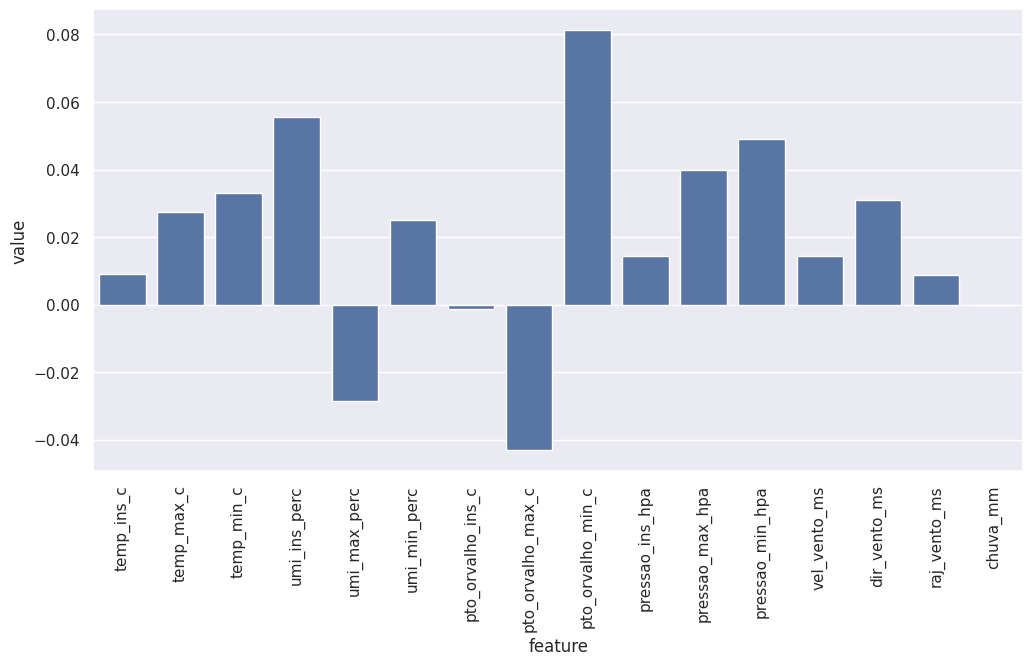

In [53]:
cols = ["temp_ins_c", 
  "temp_max_c", 
  "temp_min_c", 
  "umi_ins_perc", 
  "umi_max_perc", 
  "umi_min_perc", 
  "pto_orvalho_ins_c", 
  "pto_orvalho_max_c",
  "pto_orvalho_min_c",
  "pressao_ins_hpa", 
  "pressao_max_hpa",
  "pressao_min_hpa",
  "vel_vento_ms",
  "dir_vento_ms",
  "raj_vento_ms",
  "chuva_mm",
  "radiacao"]

df_selected = anual_df[cols]

scaler = MinMaxScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=df_selected.columns)
df_scaled = df_scaled.fillna(df_scaled.mean())

X_train = df_scaled.drop("radiacao", axis=1).values
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

Y_train = df_scaled["radiacao"].values

get_feature_importance(X_train, Y_train, cols[:-1])

# Test with 3 random columns

In [83]:
list_cols = ["temp_ins_c", "umi_ins_perc", "vel_vento_ms", "radiacao"]
df = select_and_normalize_minmax(anual_df, list_cols)

### Split data

In [84]:
janela_tempo = 12

In [85]:
X_clima, X_rad, y = criar_janelas(df, list_cols, "radiacao", janela=janela_tempo, horizonte=1)
Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val = train_test_split(X_clima, X_rad, y, test_size=0.2, random_state=42, shuffle=False)

### Create and training

In [86]:
model = create_model(len(list_cols))
training_model(model, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val)

Epoch 1/20
110/110 [==============================] - 4s 13ms/step - loss: 0.0486 - val_loss: 0.0210
Epoch 2/20
110/110 [==============================] - 2s 15ms/step - loss: 0.0107 - val_loss: 0.0195
Epoch 3/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0097 - val_loss: 0.0192
Epoch 4/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0097 - val_loss: 0.0189
Epoch 5/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0099 - val_loss: 0.0194
Epoch 6/20
110/110 [==============================] - 1s 12ms/step - loss: 0.0096 - val_loss: 0.0179
Epoch 7/20
110/110 [==============================] - 1s 12ms/step - loss: 0.0094 - val_loss: 0.0177
Epoch 8/20
110/110 [==============================] - 1s 9ms/step - loss: 0.0095 - val_loss: 0.0182
Epoch 9/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0092 - val_loss: 0.0172
Epoch 10/20
110/110 [==============================] - 1s 9ms/step - loss: 0.0090 - val_loss: 0.

In [87]:
train_pred = model.predict(x={"input_clima": Xc_train, "input_radiacao": Xr_train})
test_pred = model.predict(x={"input_clima": Xc_val, "input_radiacao": Xr_val})

28/28 [==============================] - 0s 4ms/step


In [97]:
# period = anual_df[0:train_pred.shape[0]]['data']
# plot_results(train_pred.reshape(train_pred.shape[0]), y_train, period)

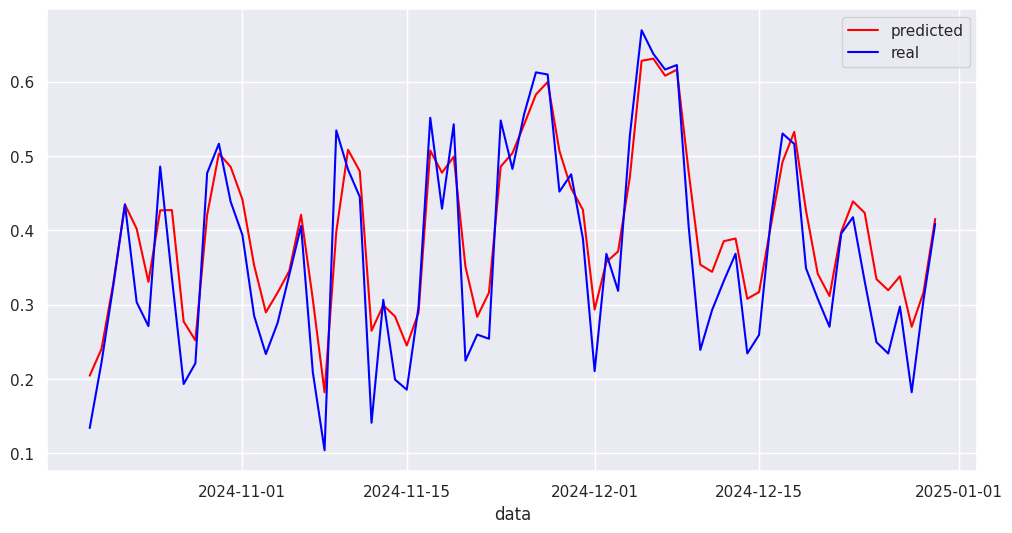

In [89]:
period = anual_df[train_pred.shape[0]:]['data'].iloc[:test_pred.shape[0]]
plot_results(test_pred.reshape(test_pred.shape[0]), y_val, period)

In [90]:
get_metrics(test_pred, y_val)

MSE:  0.017265208052261324
RMSE:  0.13139713867608124
MAE:  0.09888024449750625
R2 Score:  0.7127502235685919


# Test with another 3 random columns

Epoch 1/20
110/110 [==============================] - 4s 14ms/step - loss: 0.0536 - val_loss: 0.0246
Epoch 2/20
110/110 [==============================] - 1s 14ms/step - loss: 0.0114 - val_loss: 0.0213
Epoch 3/20
110/110 [==============================] - 1s 9ms/step - loss: 0.0102 - val_loss: 0.0200
Epoch 4/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0104 - val_loss: 0.0210
Epoch 5/20
110/110 [==============================] - 1s 9ms/step - loss: 0.0100 - val_loss: 0.0189
Epoch 6/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0095 - val_loss: 0.0193
Epoch 7/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0095 - val_loss: 0.0180
Epoch 8/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0093 - val_loss: 0.0178
Epoch 9/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0090 - val_loss: 0.0180
Epoch 10/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0090 - val_loss: 0.01

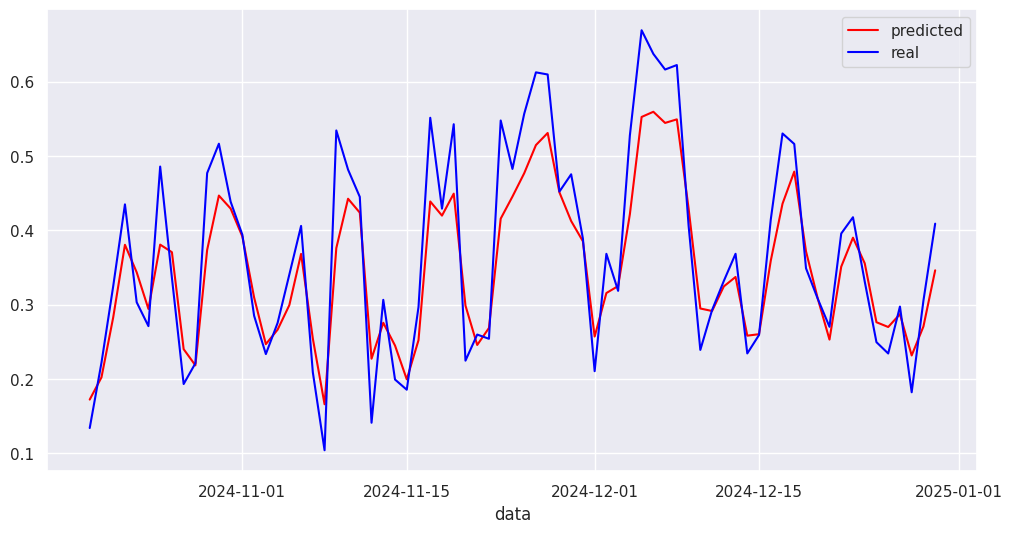

In [98]:
list_cols = ["temp_ins_c", "dir_vento_ms", "chuva_mm", "radiacao"]
df = select_and_normalize_minmax(anual_df, list_cols)

X_clima, X_rad, y = criar_janelas(df, list_cols, "radiacao", janela=janela_tempo, horizonte=1)
Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val = train_test_split(X_clima, X_rad, y, test_size=0.2, random_state=42, shuffle=False)

model = create_model(len(list_cols))
training_model(model, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val)

train_pred = model.predict(x={"input_clima": Xc_train, "input_radiacao": Xr_train})
test_pred = model.predict(x={"input_clima": Xc_val, "input_radiacao": Xr_val})

period = anual_df[train_pred.shape[0]:]['data'].iloc[:test_pred.shape[0]]
plot_results(test_pred.reshape(test_pred.shape[0]), y_val, period)

In [99]:
get_metrics(test_pred, y_val)

MSE:  0.016958010174951903
RMSE:  0.13022292492089058
MAE:  0.10112678187742889
R2 Score:  0.6740524199502


# Test with best 3 columns

In [91]:
list_cols = ["umi_min_perc", "pto_orvalho_min_c", "pressao_min_hpa", "radiacao"]
df = select_and_normalize_minmax(anual_df, list_cols)

In [92]:
X_clima, X_rad, y = criar_janelas(df, list_cols, "radiacao", janela=janela_tempo, horizonte=1)
Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val = train_test_split(X_clima, X_rad, y, test_size=0.2, random_state=42, shuffle=False)

In [93]:
model = create_model(len(list_cols))
training_model(model, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val)

Epoch 1/20
110/110 [==============================] - 4s 12ms/step - loss: 0.0396 - val_loss: 0.0216
Epoch 2/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0103 - val_loss: 0.0199
Epoch 3/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0101 - val_loss: 0.0190
Epoch 4/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0099 - val_loss: 0.0188
Epoch 5/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0097 - val_loss: 0.0206
Epoch 6/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0095 - val_loss: 0.0178
Epoch 7/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0092 - val_loss: 0.0179
Epoch 8/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0094 - val_loss: 0.0178
Epoch 9/20
110/110 [==============================] - 1s 7ms/step - loss: 0.0090 - val_loss: 0.0174
Epoch 10/20
110/110 [==============================] - 1s 8ms/step - loss: 0.0089 - val_loss: 0.017

In [94]:
train_pred = model.predict(x={"input_clima": Xc_train, "input_radiacao": Xr_train})
test_pred = model.predict(x={"input_clima": Xc_val, "input_radiacao": Xr_val})

28/28 [==============================] - 0s 3ms/step


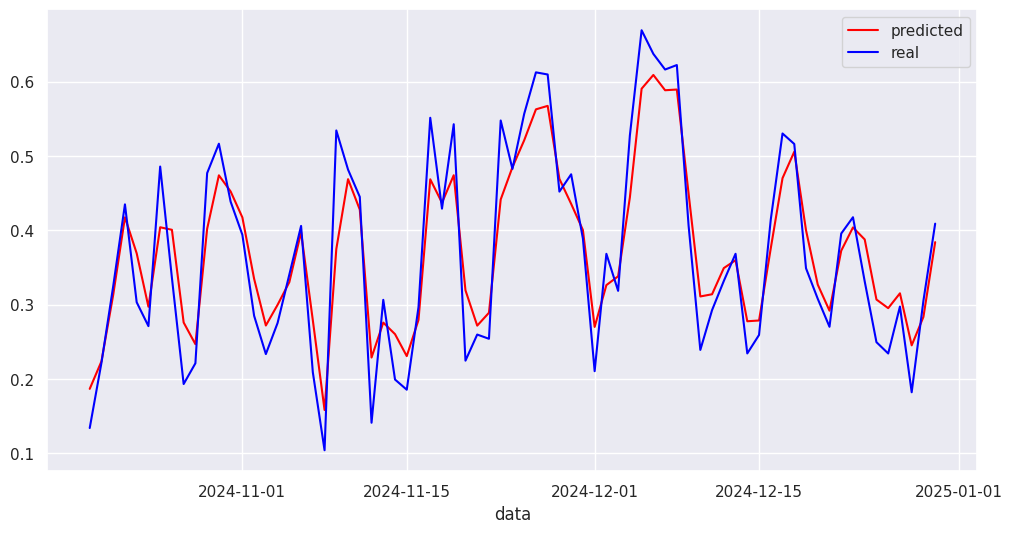

In [95]:
period = anual_df[train_pred.shape[0]:]['data'].iloc[:test_pred.shape[0]]
plot_results(test_pred.reshape(test_pred.shape[0]), y_val, period)

In [96]:
get_metrics(test_pred, y_val)

MSE:  0.016070938272784406
RMSE:  0.12677120443059775
MAE:  0.09627290282244526
R2 Score:  0.7142218944643806


In [101]:
12*0.8

9.600000000000001